In [29]:
from scipy.linalg import svd
import numpy as np

def principal_component_analysis(data):
    print("Starting PCA analysis...")
    
    # Input validation
    if data.ndim != 2:
        raise ValueError("Data must be 2D (samples × features)")
    
    n_samples, n_features = data.shape
    print(f"Data shape: {data.shape} ({n_samples} samples, {n_features} features)")
    
    # Center data around the mean
    data_centered = data - data.mean(axis=0)
    
    print(f"Mean-centered data. Range: [{data_centered.min():.3f}, {data_centered.max():.3f}]")
    
    # Apply SVD decomposition
    U, singular_values, Vt = svd(data_centered, full_matrices=False)
    
    # Compute eigenvalues from singular values
    eigenvalues = np.square(singular_values[:n_features]) / (n_samples - 1)
    
    # Principal components are rows of Vt transposed (columns of V)
    principal_components = Vt.T
    
    print(f"Eigenvalues sorted? {np.all(eigenvalues[:-1] >= eigenvalues[1:])}")
    print(f"First 5 eigenvalues: {eigenvalues[:5]}")
    
    return principal_components, eigenvalues, data_centered

In [30]:
if __name__ == "__main__":
    # Read the hyperspectral data
    print("Reading hyperspectral data...")
    img = spy.open_image("tait_labsphere.hdr")
    
    print(f"\nImage info:")
    print(f"  Shape: {img.shape}")
    print(f"  Rows: {img.nrows}, Cols: {img.ncols}, Bands: {img.nbands}")
    
    # Load data into memory
    data = img.load()
    
    # Reshape from 3D (rows, cols, bands) to 2D (pixels, bands)
    rows, cols, bands = data.shape
    reshaped_data = data.reshape(rows * cols, bands)
    
    print(f"\nReshaped data: {reshaped_data.shape}")
    
    # Apply PCA
    print("\n" + "="*60)
    print("PERFORMING PCA")
    print("="*60)
    pcs, eigenvalues, centered_data = principal_component_analysis(reshaped_data)
    
    # Calculate variance explained
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = (eigenvalues / total_variance) * 100
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    print("\n" + "="*60)
    print("VARIANCE EXPLAINED")
    print("="*60)
    print(f"\nFirst 10 components:")
    for i in range(min(10, len(explained_variance_ratio))):
        print(f"PC{i+1}: {explained_variance_ratio[i]:.2f}% (Cumulative: {cumulative_variance[i]:.2f}%)")
    
    # Find number of components needed for 95% and 99% variance
    n_95 = np.argmax(cumulative_variance >= 95) + 1
    n_99 = np.argmax(cumulative_variance >= 99) + 1
    
    print(f"\nComponents needed for 95% variance: {n_95}")
    print(f"Components needed for 99% variance: {n_99}")
    
    print("\nPCA Complete!")

Reading hyperspectral data...

Image info:
  Shape: (1039, 1087, 272)
  Rows: 1039, Cols: 1087, Bands: 272

Reshaped data: (1129393, 272)

PERFORMING PCA
Starting PCA analysis...
Data shape: (1129393, 272) (1129393 samples, 272 features)
Mean-centered data. Range: [-1.401, 9.906]
Eigenvalues sorted? True
First 5 eigenvalues: [157.98787    37.68985     4.094432    1.2043008   0.6417511]

VARIANCE EXPLAINED

First 10 components:
PC1: 77.11% (Cumulative: 77.11%)
PC2: 18.40% (Cumulative: 95.50%)
PC3: 2.00% (Cumulative: 97.50%)
PC4: 0.59% (Cumulative: 98.09%)
PC5: 0.31% (Cumulative: 98.40%)
PC6: 0.09% (Cumulative: 98.50%)
PC7: 0.06% (Cumulative: 98.56%)
PC8: 0.06% (Cumulative: 98.61%)
PC9: 0.05% (Cumulative: 98.66%)
PC10: 0.05% (Cumulative: 98.71%)

Components needed for 95% variance: 2
Components needed for 99% variance: 19

PCA Complete!


Transformation matrix shape: (272, 10)
Original centered data shape: (1129393, 272)
Transformed data shape: (1129393, 10)
Reshaped PC images: (1039, 1087, 10)

Saved plot to 'first_10_principal_components.png'


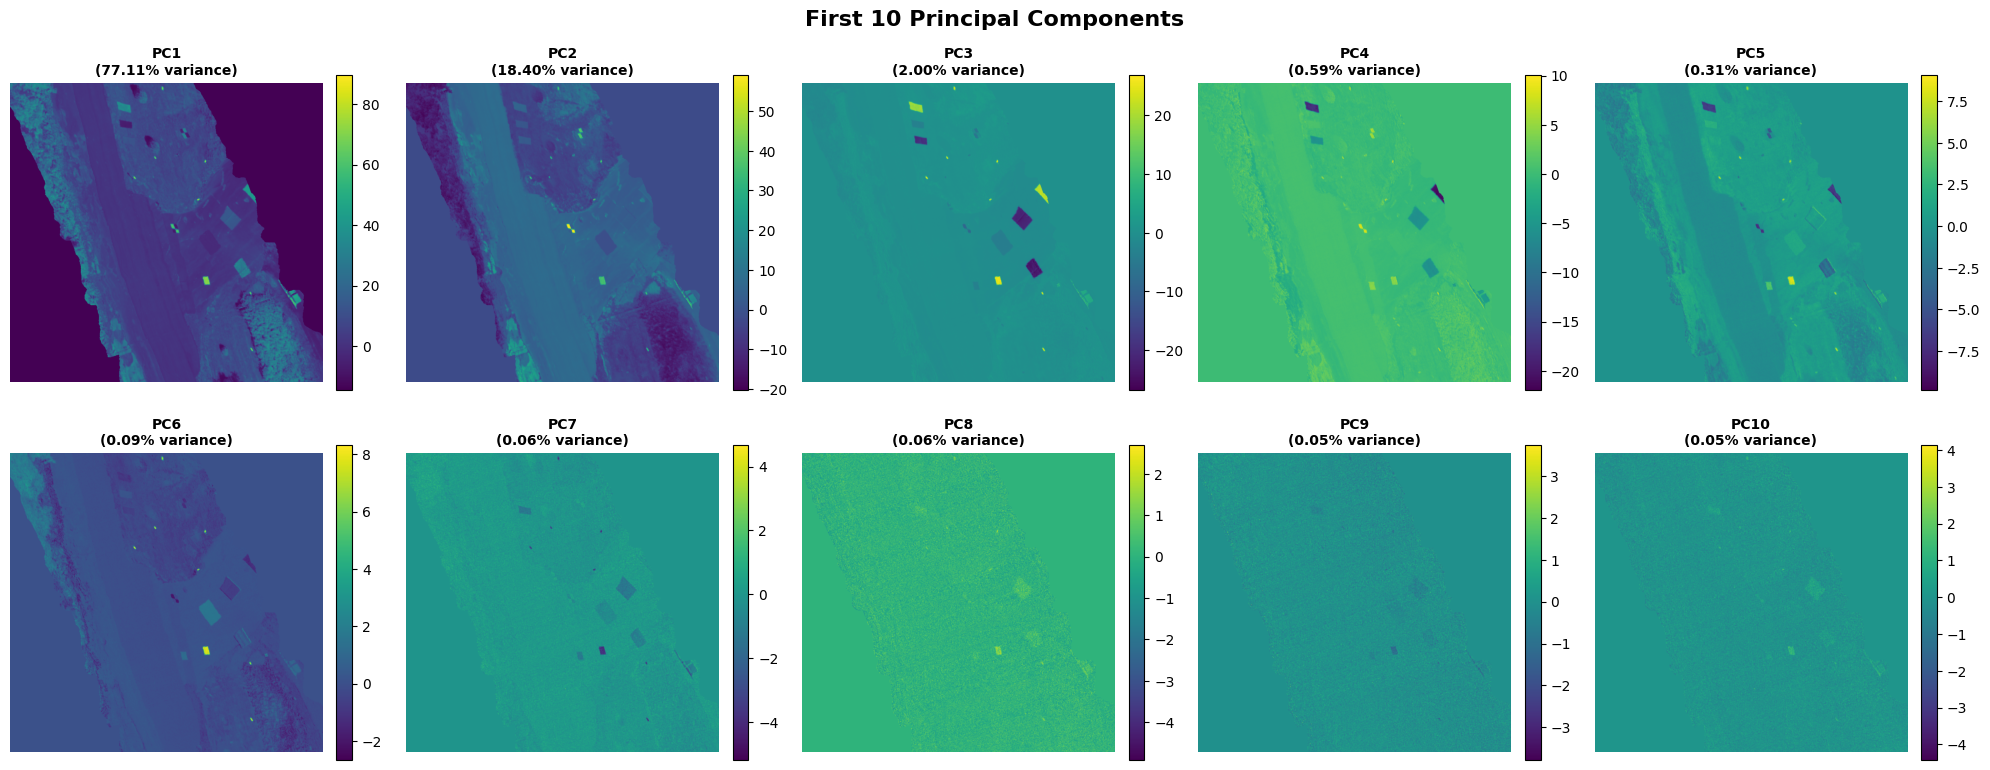


PRINCIPAL COMPONENT STATISTICS

PC1:
  Variance Explained: 77.11%
  Min value: -14.3348
  Max value: 89.7196
  Mean value: 0.0000
  Std deviation: 12.5693

PC2:
  Variance Explained: 18.40%
  Min value: -20.1726
  Max value: 59.1617
  Mean value: -0.0000
  Std deviation: 6.1392

PC3:
  Variance Explained: 2.00%
  Min value: -26.7066
  Max value: 26.9298
  Mean value: 0.0000
  Std deviation: 2.0235

PC4:
  Variance Explained: 0.59%
  Min value: -21.8993
  Max value: 10.0794
  Mean value: 0.0000
  Std deviation: 1.0974

PC5:
  Variance Explained: 0.31%
  Min value: -9.8028
  Max value: 9.0806
  Mean value: -0.0000
  Std deviation: 0.8011

PC6:
  Variance Explained: 0.09%
  Min value: -2.6603
  Max value: 8.3186
  Mean value: 0.0000
  Std deviation: 0.4384

PC7:
  Variance Explained: 0.06%
  Min value: -5.1819
  Max value: 4.6669
  Mean value: 0.0000
  Std deviation: 0.3451

PC8:
  Variance Explained: 0.06%
  Min value: -4.9133
  Max value: 2.6909
  Mean value: 0.0000
  Std deviation: 0.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the first 10 principal components (transformation matrix)
n_components = 10
transformation_matrix = pcs[:, :n_components]  # Shape: (bands, 10)

print(f"Transformation matrix shape: {transformation_matrix.shape}")
print(f"Original centered data shape: {centered_data.shape}")

# Transform the data to reduced dimensions
# Matrix multiplication: (pixels, bands) @ (bands, 10) = (pixels, 10)
transformed_data = np.dot(centered_data,transformation_matrix)

print(f"Transformed data shape: {transformed_data.shape}")

# Reshape to match the original image size
# From (rows*cols, 10) to (rows, cols, 10)
pc_images = transformed_data.reshape(rows, cols, n_components)

print(f"Reshaped PC images: {pc_images.shape}")

# Calculate variance explained for titles
total_variance = np.sum(eigenvalues)
explained_variance_ratio = (eigenvalues / total_variance) * 100

# Plot the first 10 principal components separately
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('First 10 Principal Components', fontsize=16, fontweight='bold')

# Flatten axes array for easier iteration
axes = axes.flatten()

for i in range(n_components):
    # Get the i-th principal component image
    pc_img = pc_images[:, :, i]
    
    # Plot
    im = axes[i].imshow(pc_img, cmap='viridis')
    axes[i].set_title(f'PC{i+1}\n({explained_variance_ratio[i]:.2f}% variance)', 
                      fontsize=10, fontweight='bold')
    axes[i].axis('off')
    
   
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('first_10_principal_components.png', dpi=300, bbox_inches='tight')
print("\nSaved plot to 'first_10_principal_components.png'")
plt.show()

# Print summary statistics for each PC
print("\n" + "="*60)
print("PRINCIPAL COMPONENT STATISTICS")
print("="*60)
for i in range(n_components):
    pc_img = pc_images[:, :, i]
    print(f"\nPC{i+1}:")
    print(f"  Variance Explained: {explained_variance_ratio[i]:.2f}%")
    print(f"  Min value: {pc_img.min():.4f}")
    print(f"  Max value: {pc_img.max():.4f}")
    print(f"  Mean value: {pc_img.mean():.4f}")
    print(f"  Std deviation: {pc_img.std():.4f}")

Total number of PCs: 272
Extracting PCs from index 262 to 271
Transformation matrix shape: (272, 10)
Original centered data shape: (1129393, 272)
Transformed data shape: (1129393, 10)
Reshaped PC images: (1039, 1087, 10)

Saved plot to 'last_10_principal_components.png'


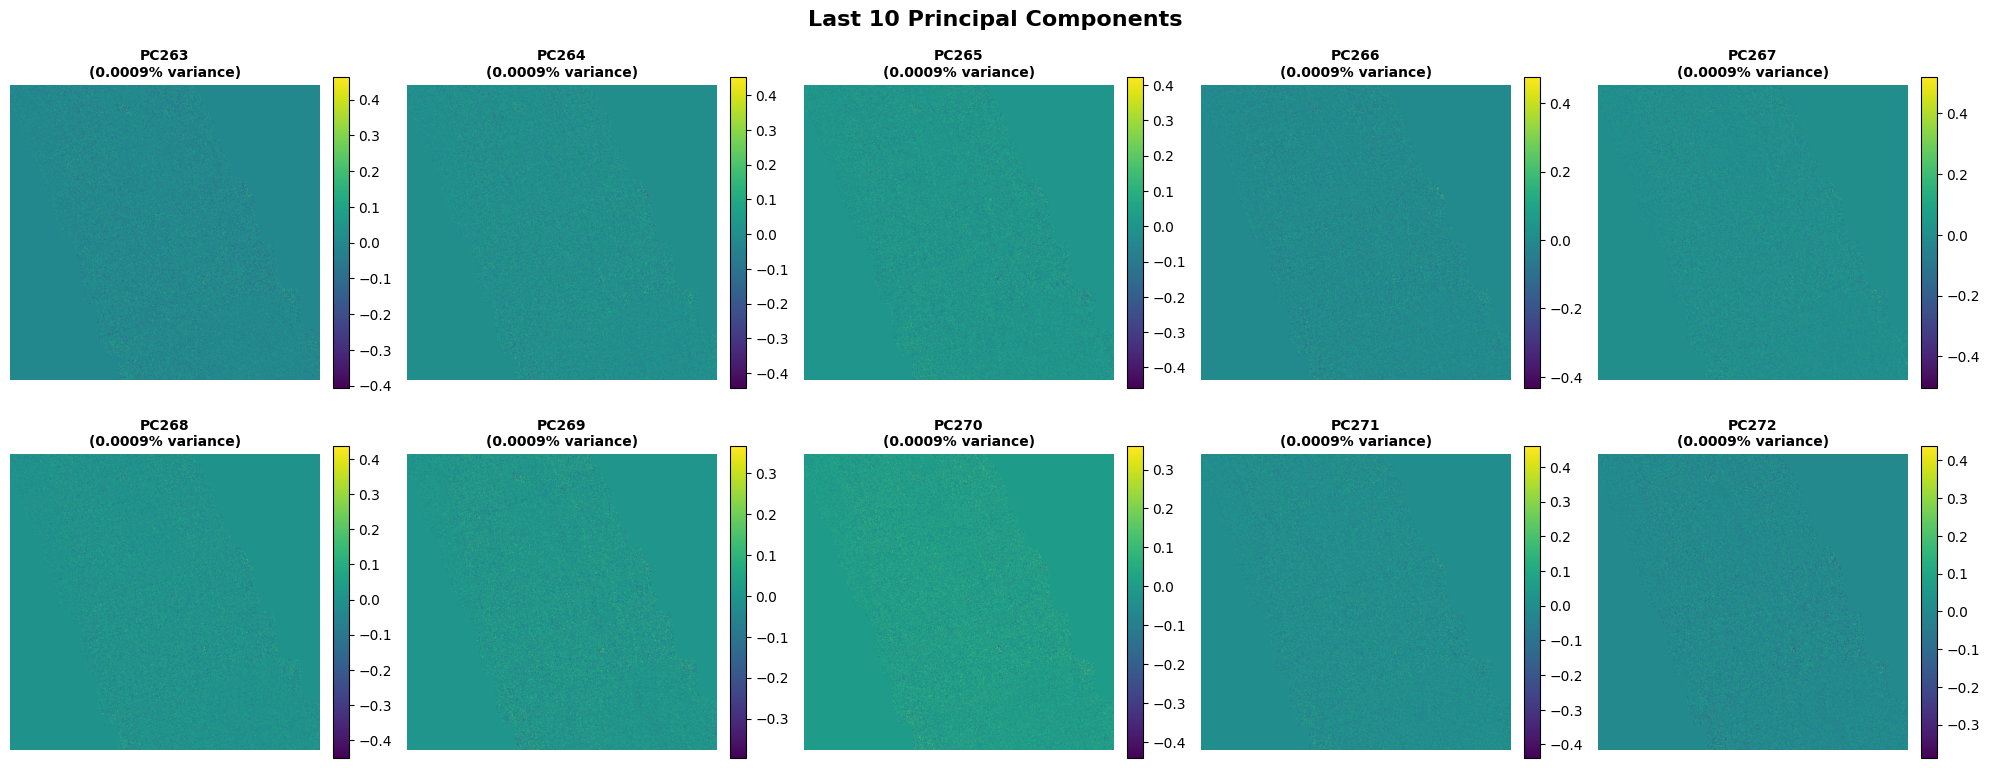


LAST 10 PRINCIPAL COMPONENT STATISTICS

PC263:
  Variance Explained: 0.0009%
  Min value: -0.4072
  Max value: 0.4642
  Mean value: -0.0000
  Std deviation: 0.0436

PC264:
  Variance Explained: 0.0009%
  Min value: -0.4441
  Max value: 0.4532
  Mean value: -0.0000
  Std deviation: 0.0435

PC265:
  Variance Explained: 0.0009%
  Min value: -0.4593
  Max value: 0.4237
  Mean value: -0.0000
  Std deviation: 0.0434

PC266:
  Variance Explained: 0.0009%
  Min value: -0.4337
  Max value: 0.4775
  Mean value: -0.0000
  Std deviation: 0.0434

PC267:
  Variance Explained: 0.0009%
  Min value: -0.5051
  Max value: 0.5210
  Mean value: -0.0000
  Std deviation: 0.0433

PC268:
  Variance Explained: 0.0009%
  Min value: -0.4508
  Max value: 0.4357
  Mean value: -0.0000
  Std deviation: 0.0432

PC269:
  Variance Explained: 0.0009%
  Min value: -0.3961
  Max value: 0.3647
  Mean value: -0.0000
  Std deviation: 0.0432

PC270:
  Variance Explained: 0.0009%
  Min value: -0.4418
  Max value: 0.3594
  Mean

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pca_model.principal_component_analysis() has already been run
# and we have: pcs, eigenvalues, centered_data, rows, cols, bands

# Extract the LAST 10 principal components (transformation matrix)
n_components = 10
total_pcs = pcs.shape[1]  # Total number of principal components
start_idx = total_pcs - n_components  # Starting index for last 10

transformation_matrix = pcs[:, start_idx:]  # Shape: (bands, 10)

print(f"Total number of PCs: {total_pcs}")
print(f"Extracting PCs from index {start_idx} to {total_pcs-1}")
print(f"Transformation matrix shape: {transformation_matrix.shape}")
print(f"Original centered data shape: {centered_data.shape}")

# Transform the data to reduced dimensions
# Matrix multiplication: (pixels, bands) @ (bands, 10) = (pixels, 10)
transformed_data = centered_data @ transformation_matrix

print(f"Transformed data shape: {transformed_data.shape}")

# Reshape to match the original image size
# From (rows*cols, 10) to (rows, cols, 10)
pc_images = transformed_data.reshape(rows, cols, n_components)

print(f"Reshaped PC images: {pc_images.shape}")

# Calculate variance explained for titles
total_variance = np.sum(eigenvalues)
explained_variance_ratio = (eigenvalues / total_variance) * 100

# Get variance for last 10 components
last_10_variance = explained_variance_ratio[start_idx:]

# Plot the last 10 principal components separately
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Last 10 Principal Components', fontsize=16, fontweight='bold')

# Flatten axes array for easier iteration
axes = axes.flatten()

for i in range(n_components):
    # Get the i-th principal component image
    pc_img = pc_images[:, :, i]
    
    # Actual PC number (e.g., PC356, PC357, etc.)
    pc_number = start_idx + i + 1
    
    # Plot
    im = axes[i].imshow(pc_img, cmap='viridis')
    axes[i].set_title(f'PC{pc_number}\n({last_10_variance[i]:.4f}% variance)', 
                      fontsize=10, fontweight='bold')
    axes[i].axis('off')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('last_10_principal_components.png', dpi=300, bbox_inches='tight')
print("\nSaved plot to 'last_10_principal_components.png'")
plt.show()

# Print summary statistics for each PC
print("\n" + "="*60)
print("LAST 10 PRINCIPAL COMPONENT STATISTICS")
print("="*60)
for i in range(n_components):
    pc_img = pc_images[:, :, i]
    pc_number = start_idx + i + 1
    print(f"\nPC{pc_number}:")
    print(f"  Variance Explained: {last_10_variance[i]:.4f}%")
    print(f"  Min value: {pc_img.min():.4f}")
    print(f"  Max value: {pc_img.max():.4f}")
    print(f"  Mean value: {pc_img.mean():.4f}")
    print(f"  Std deviation: {pc_img.std():.4f}")

# Summary comparison
print("\n" + "="*60)
print("COMPARISON: FIRST 10 vs LAST 10")
print("="*60)
first_10_total = np.sum(explained_variance_ratio[:10])
last_10_total = np.sum(last_10_variance)
print(f"Total variance in FIRST 10 PCs: {first_10_total:.2f}%")
print(f"Total variance in LAST 10 PCs: {last_10_total:.4f}%")
print(f"Ratio: {first_10_total/last_10_total:.2f}x more variance in first 10")

Explanation: 
First 10 Principal Components
The dominant spectral patterns of the scene are captured by the first few PCs in decreasing order of significance.  The main contrast between the two main land cover types—vegetation and agricultural fields—is represented by PC1 (77.11% variance), whereas PC2 (18.40% variance) makes a distinction between various vegetation types and crop conditions.  With yellow/cyan highlights designating particular features, PC3-PC5 (2.00%, 0.59%, 0.31% variance) show increasingly finer distinctions such as field boundaries and water bodies.  Though their increasingly homogeneous appearance indicates they are starting to capture noise rather than significant spectral information, PC6–PC10 (each <0.1% variance) capture subtle field-level variations in crop health or soil moisture.  This hierarchical structure shows how PCA effectively distinguishes between significant and minor variations in land cover.

Last 10 Principal Components
The last 10 PCs (PC263-PC272, each ≤0.0001% variance) appear nearly uniform with flat cyan/teal tones and no coherent spatial structure, representing pure noise from sensor artifacts, atmospheric effects, and random fluctuations rather than meaningful land cover information. This demonstrates PCA's effectiveness for dimensionality reduction: over 99% of spectral information is captured in the first few components, while these last components contain only residual noise that can be safely discarded without losing any meaningful scene data.


PCA RECONSTRUCTION ERROR ANALYSIS

Original data shape: (1129393, 272)
Total features (d): 272
Evaluating reconstruction error for K = [1, 10, 50, 100, 272]

--- Computing reconstruction error for K = 1 ---
Transformation matrix shape: (272, 1)
Reduced data shape: (1129393, 1)
Reconstructed data shape: (1129393, 272)
Mean L2 reconstruction error: 5.429659
Min error: 1.026736
Max error: 61.067440
Std error: 4.173574

--- Computing reconstruction error for K = 10 ---
Transformation matrix shape: (272, 10)
Reduced data shape: (1129393, 10)
Reconstructed data shape: (1129393, 272)
Mean L2 reconstruction error: 1.270036
Min error: 0.071752
Max error: 9.976559
Std error: 1.013056

--- Computing reconstruction error for K = 50 ---
Transformation matrix shape: (272, 50)
Reduced data shape: (1129393, 50)
Reconstructed data shape: (1129393, 272)
Mean L2 reconstruction error: 0.829851
Min error: 0.011579
Max error: 8.549442
Std error: 0.683571

--- Computing reconstruction error for K = 100 ---
T

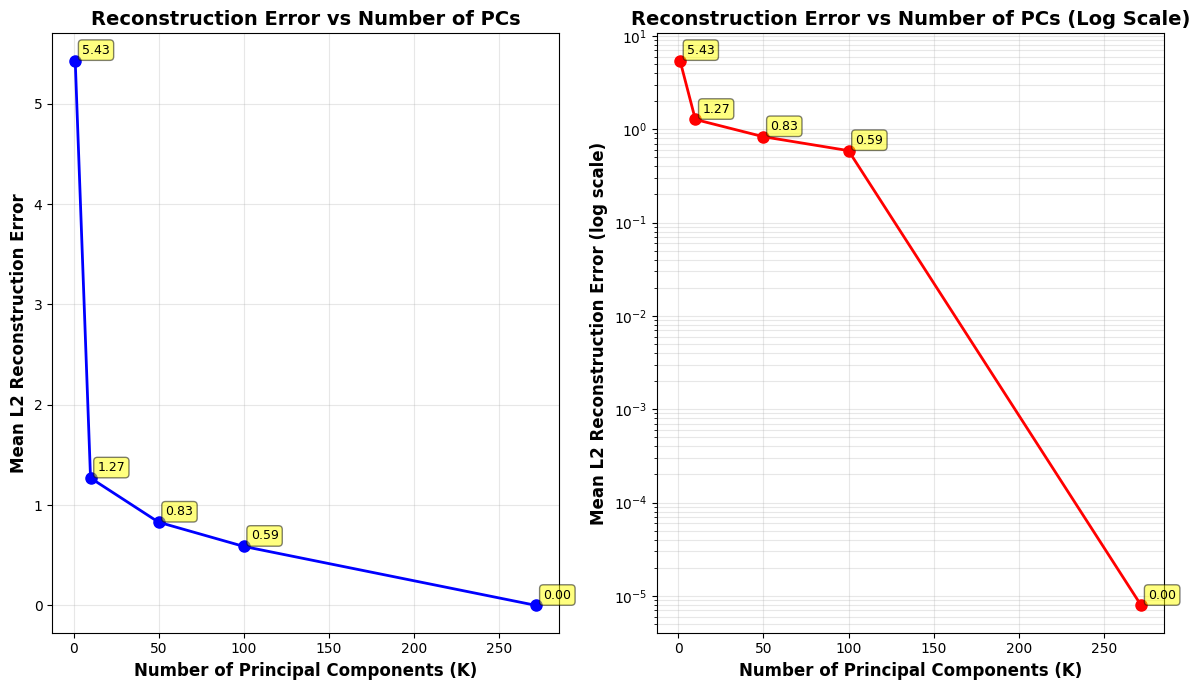


VARIANCE EXPLAINED BY SELECTED K
K =   1: 77.11% variance explained
K =  10: 98.71% variance explained
K =  50: 99.44% variance explained
K = 100: 99.72% variance explained
K = 272: 100.00% variance explained


In [33]:
import numpy as np
import matplotlib.pyplot as plt



# Selected number of principal components to evaluate
d = bands  # Total number of features
selected_k = [1, 10, 50, 100, d]

print("="*60)
print("PCA RECONSTRUCTION ERROR ANALYSIS")
print("="*60)
print(f"\nOriginal data shape: {centered_data.shape}")
print(f"Total features (d): {d}")
print(f"Evaluating reconstruction error for K = {selected_k}")

# Store results
reconstruction_errors = []
k_values = []

for k in selected_k:
    if k > d:
        print(f"\nSkipping K={k} (exceeds total features d={d})")
        continue
    
    print(f"\n--- Computing reconstruction error for K = {k} ---")
    
    # Step 1: Forward transform - Project data onto first K principal components
    # Extract first K eigenvectors as transformation matrix
    transformation_matrix = pcs[:, :k]  # Shape: (d, k)
    print(f"Transformation matrix shape: {transformation_matrix.shape}")
    
    # Transform to reduced PC space: (pixels, d) @ (d, k) = (pixels, k)
    reduced_data = centered_data @ transformation_matrix
    print(f"Reduced data shape: {reduced_data.shape}")
    
    # Step 2: Backward transform - Reconstruct data in original space
    # Use transpose of transformation matrix: (pixels, k) @ (k, d) = (pixels, d)
    reconstructed_data = reduced_data @ transformation_matrix.T
    print(f"Reconstructed data shape: {reconstructed_data.shape}")
    
    # Step 3: Compute L2 reconstruction error
    # L2 distance (Euclidean distance) between original and reconstructed
    # Error = ||X - X_reconstructed||_2
    diff = centered_data - reconstructed_data
    
    # Compute L2 norm for each pixel (row)
    l2_errors = np.linalg.norm(diff, axis=1)  # L2 norm across features
    
    # Mean reconstruction error across all pixels
    mean_error = np.mean(l2_errors)
    
    print(f"Mean L2 reconstruction error: {mean_error:.6f}")
    
    # Store results
    k_values.append(k)
    reconstruction_errors.append(mean_error)
    
    # Additional statistics
    print(f"Min error: {np.min(l2_errors):.6f}")
    print(f"Max error: {np.max(l2_errors):.6f}")
    print(f"Std error: {np.std(l2_errors):.6f}")

# Convert to arrays for easier manipulation
k_values = np.array(k_values)
reconstruction_errors = np.array(reconstruction_errors)

# Print summary table
print("\n" + "="*60)
print("RECONSTRUCTION ERROR SUMMARY")
print("="*60)
print(f"{'K (# PCs)':<15} {'Mean L2 Error':<20} {'Error Reduction':<20}")
print("-" * 60)
for i, k in enumerate(k_values):
    if i == 0:
        print(f"{k:<15} {reconstruction_errors[i]:<20.6f} {'baseline':<20}")
    else:
        reduction = ((reconstruction_errors[0] - reconstruction_errors[i]) / reconstruction_errors[0]) * 100
        print(f"{k:<15} {reconstruction_errors[i]:<20.6f} {reduction:.2f}%")

# Visualize reconstruction error as a function of K
plt.figure(figsize=(12, 7))

# Main plot
plt.subplot(1, 2, 1)
plt.plot(k_values, reconstruction_errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components (K)', fontsize=12, fontweight='bold')
plt.ylabel('Mean L2 Reconstruction Error', fontsize=12, fontweight='bold')
plt.title('Reconstruction Error vs Number of PCs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels on points
for i, (k, error) in enumerate(zip(k_values, reconstruction_errors)):
    plt.annotate(f'{error:.2f}', 
                xy=(k, error), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# Log scale plot (better for seeing differences)
plt.subplot(1, 2, 2)
plt.plot(k_values, reconstruction_errors, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components (K)', fontsize=12, fontweight='bold')
plt.ylabel('Mean L2 Reconstruction Error (log scale)', fontsize=12, fontweight='bold')
plt.title('Reconstruction Error vs Number of PCs (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, which='both')

# Add value labels
for i, (k, error) in enumerate(zip(k_values, reconstruction_errors)):
    plt.annotate(f'{error:.2f}', 
                xy=(k, error), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('pca_reconstruction_error.png', dpi=300, bbox_inches='tight')
print("\nSaved plot to 'pca_reconstruction_error.png'")
plt.show()

# Calculate and display variance explained
print("\n" + "="*60)
print("VARIANCE EXPLAINED BY SELECTED K")
print("="*60)
total_variance = np.sum(eigenvalues)
for k in k_values:
    if k <= len(eigenvalues):
        variance_explained = (np.sum(eigenvalues[:k]) / total_variance) * 100
        print(f"K = {k:3d}: {variance_explained:.2f}% variance explained")

2.d

99% VARIANCE RECONSTRUCTION ANALYSIS

Total variance: 204.887802
Number of eigenvalues: 272

Number of PCs for 99% variance: 19
Actual variance explained: 99.0188%

Original PC matrix shape: (272, 272)
Modified PC matrix shape: (272, 272)
Non-zero columns in modified matrix: 19

Performing forward transform...
Performing backward transform...
Reconstructed image shape: (1039, 1087, 272)

Total pixels: 1129393
Valid data pixels: 729978
No-data pixels masked: 399415

SELECTED PIXELS FOR COMPARISON
1. Dark Material ( Shadow/Dark Vegetation)
   Location: Row 649, Col 656
   Mean intensity: 0.9706
2. Medium-Dark Material (Soil/Rock)
   Location: Row 703, Col 528
   Mean intensity: 1.0906
3. Medium Material ( Vegetation)
   Location: Row 247, Col 599
   Mean intensity: 1.1745
4. Medium-Bright Material (Concrete/Road)
   Location: Row 193, Col 726
   Mean intensity: 1.3285
5. Bright Material ( Bright Surface/Building)
   Location: Row 322, Col 172
   Mean intensity: 1.7654

Saved spectral com

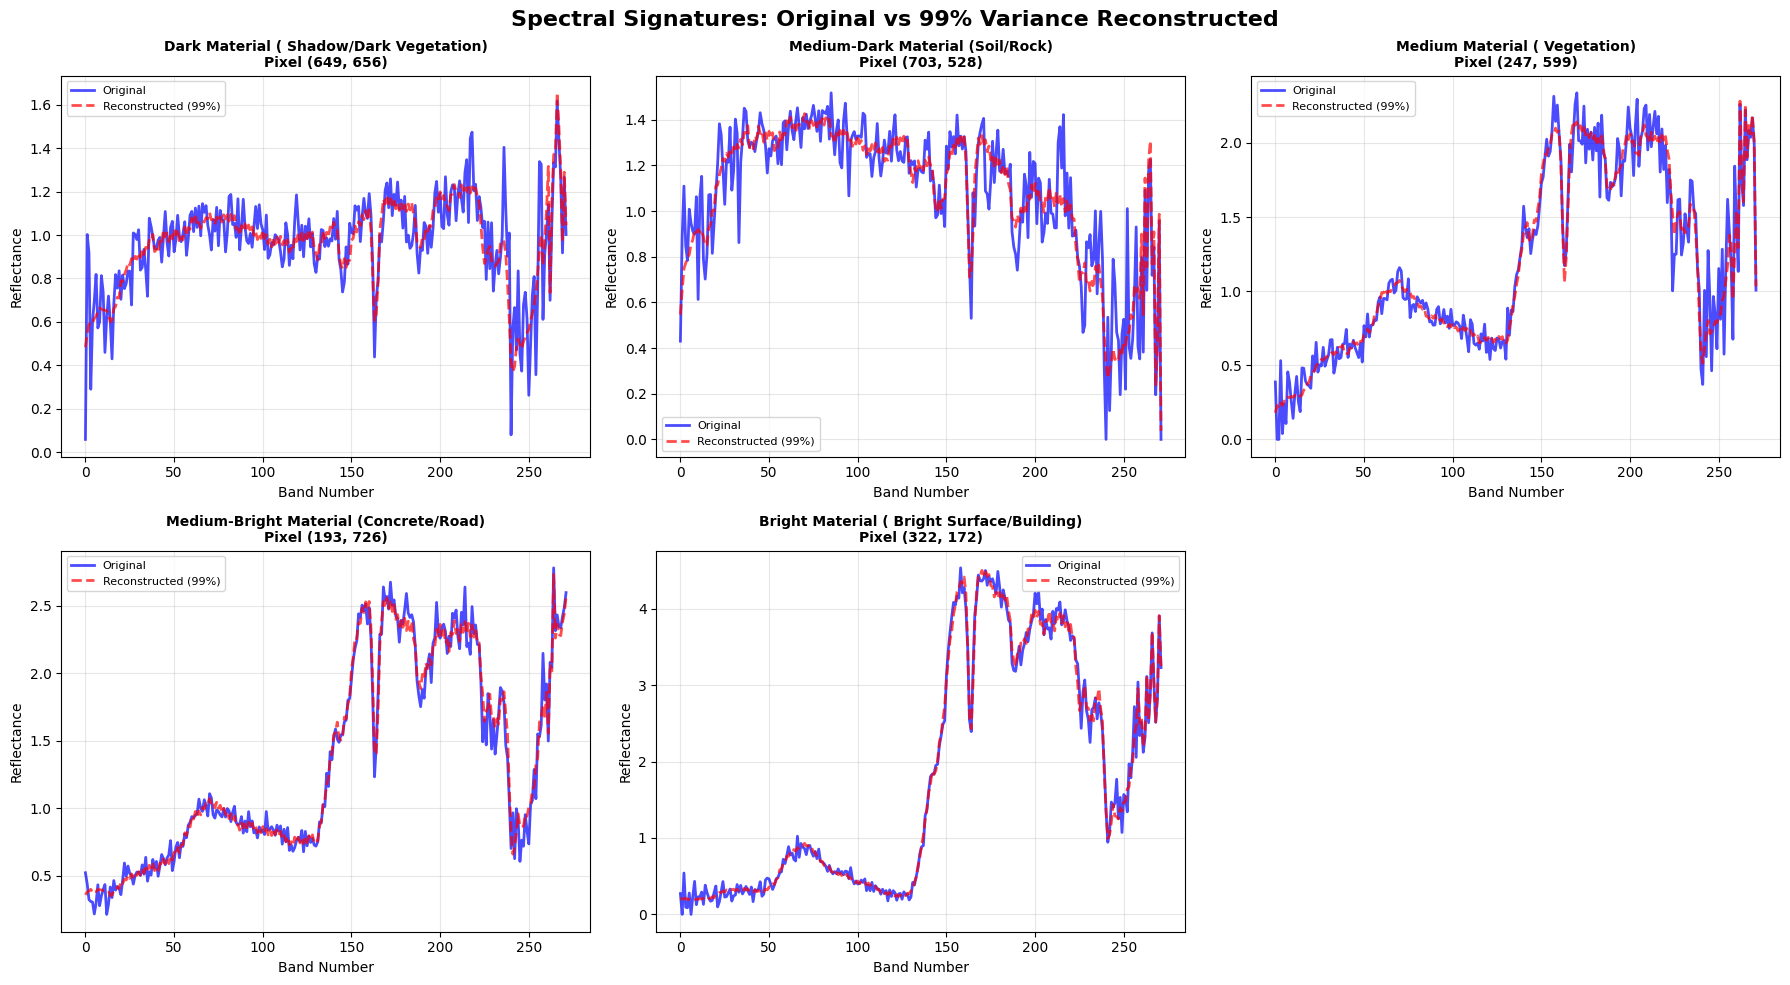


SIGNAL-TO-NOISE RATIO ANALYSIS

Original Data:
  Mean SNR across all bands: 1.8747
  Min SNR: 1.4051
  Max SNR: 2.6240
  Std of SNR: 0.2735

Reconstructed Data (99% variance):
  Mean SNR across all bands: 1.9169
  Min SNR: 1.4292
  Max SNR: 2.6391
  Std of SNR: 0.2858

SNR Improvement Factor: 1.0225x

Saved SNR comparison plot to 'snr_comparison_99variance.png'


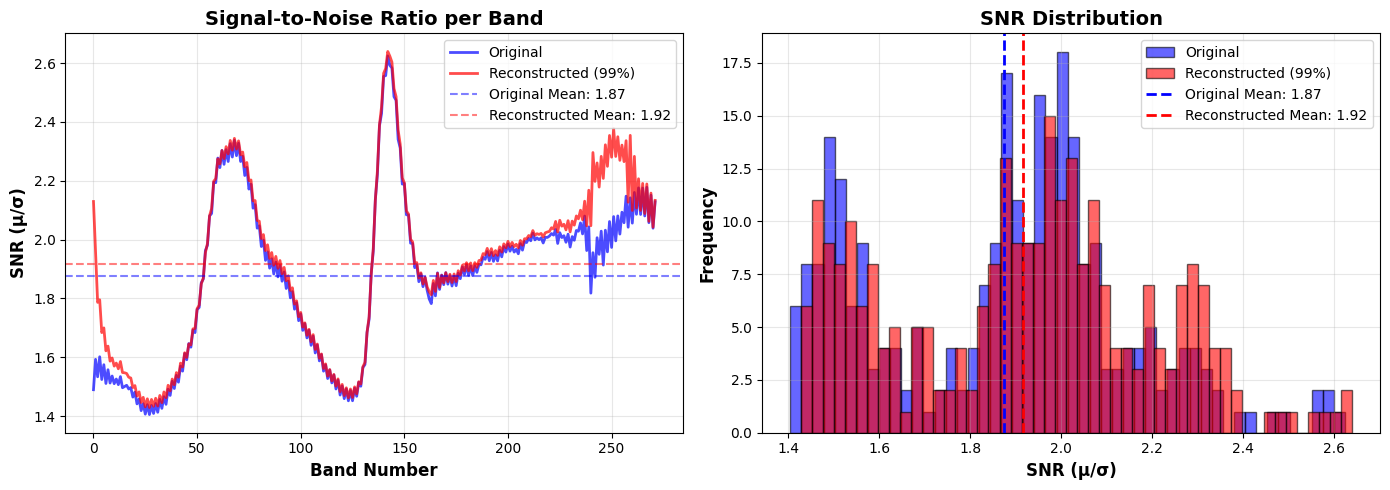


SUMMARY
PCs retained: 19 out of 272 (6.99%)
Variance explained: 99.0188%
Original mean SNR: 1.8747
Reconstructed mean SNR: 1.9169
SNR improvement: 2.25%


In [35]:
import numpy as np
import matplotlib.pyplot as plt



# Calculate mean array (needed for reconstruction)
mean_arr = np.mean(reshaped_data, axis=0)  # Shape: (bands,)

print("="*60)
print("99% VARIANCE RECONSTRUCTION ANALYSIS")
print("="*60)

# Step 1: Compute explained variance ratio for each PC
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"\nTotal variance: {total_variance:.6f}")
print(f"Number of eigenvalues: {len(eigenvalues)}")

# Step 2: Find number of PCs needed for 99% variance
n_pcs_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"\nNumber of PCs for 99% variance: {n_pcs_99}")
print(f"Actual variance explained: {cumulative_variance[n_pcs_99-1]*100:.4f}%")

# Step 3: Create modified band × band PC matrix
# Keep first n_pcs_99 components, set rest to zero
modified_pcs = pcs.copy()  # Shape: (bands, bands)
modified_pcs[:, n_pcs_99:] = 0  # Zero out components beyond 99%

print(f"\nOriginal PC matrix shape: {pcs.shape}")
print(f"Modified PC matrix shape: {modified_pcs.shape}")
print(f"Non-zero columns in modified matrix: {n_pcs_99}")

# Step 4: Reconstruct data using modified PC matrix
# Forward transform with modified PCs
print("\nPerforming forward transform...")
reduced_data = np.dot(centered_data, modified_pcs)  # (pixels, bands)

# Backward transform to reconstruct
print("Performing backward transform...")
reconstructed_centered = np.dot(reduced_data,modified_pcs.T)  # (pixels, bands)

# Add mean back to get reconstructed data in original space
reconstructed_data = reconstructed_centered + mean_arr

# Original data (add mean back to centered_data)
original_data = centered_data + mean_arr

# Reshape to image format
original_image = original_data.reshape(rows, cols, bands)
reconstructed_image = reconstructed_centered.reshape(rows, cols, bands) + mean_arr

print(f"Reconstructed image shape: {reconstructed_image.shape}")

# Step 5: Create no-data mask
# Identify no-data pixels 
# Sum across all bands to identify pixels with data
pixel_sums = np.sum(original_image, axis=2)
mask = pixel_sums > np.percentile(pixel_sums, 1)  # Mask out bottom 1% as no-data

print(f"\nTotal pixels: {rows * cols}")
print(f"Valid data pixels: {np.sum(mask)}")
print(f"No-data pixels masked: {np.sum(~mask)}")

# Step 6: Select five interesting pixels and their materials
# Display the image to help select pixels
mean_intensity = np.mean(original_image, axis=2)

# Select 5 diverse pixels from different brightness regions
# Find pixels with valid data in different intensity ranges
valid_pixels = np.where(mask)
intensities = mean_intensity[valid_pixels]

# Select pixels from different percentiles
percentiles = [10, 30, 50, 70, 90]
selected_pixels = []
pixel_labels = [
    "Dark Material ( Shadow/Dark Vegetation)",
    "Medium-Dark Material (Soil/Rock)",
    "Medium Material ( Vegetation)",
    "Medium-Bright Material (Concrete/Road)",
    "Bright Material ( Bright Surface/Building)"
]

for p in percentiles:
    target_intensity = np.percentile(intensities, p)
    idx = np.argmin(np.abs(intensities - target_intensity))
    pixel_row = valid_pixels[0][idx]
    pixel_col = valid_pixels[1][idx]
    selected_pixels.append((pixel_row, pixel_col))

print("\n" + "="*60)
print("SELECTED PIXELS FOR COMPARISON")
print("="*60)
for i, (r, c) in enumerate(selected_pixels):
    print(f"{i+1}. {pixel_labels[i]}")
    print(f"   Location: Row {r}, Col {c}")
    print(f"   Mean intensity: {mean_intensity[r, c]:.4f}")

# Step 7: Plot spectral signatures for five pixels
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Spectral Signatures: Original vs 99% Variance Reconstructed', 
             fontsize=16, fontweight='bold')
axes = axes.flatten()

wavelengths = np.arange(bands) 

for i, (r, c) in enumerate(selected_pixels):
    ax = axes[i]
    
    # Get spectral signatures
    original_spectrum = original_image[r, c, :]
    reconstructed_spectrum = reconstructed_image[r, c, :]
    
    # Plot
    ax.plot(wavelengths, original_spectrum, 'b-', linewidth=2, label='Original', alpha=0.7)
    ax.plot(wavelengths, reconstructed_spectrum, 'r--', linewidth=2, label='Reconstructed (99%)', alpha=0.7)
    
    ax.set_xlabel('Band Number', fontsize=10)
    ax.set_ylabel('Reflectance', fontsize=10)
    ax.set_title(f'{pixel_labels[i]}\nPixel ({r}, {c})', fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('spectral_comparison_99variance.png', dpi=300, bbox_inches='tight')
print("\nSaved spectral comparison plot to 'spectral_comparison_99variance.png'")
plt.show()

# Step 8: Calculate Signal-to-Noise Ratio (SNR) = μ/σ
print("\n" + "="*60)
print("SIGNAL-TO-NOISE RATIO ANALYSIS")
print("="*60)

# Apply mask to get only valid pixels
original_masked = original_image[mask, :] 
reconstructed_masked = reconstructed_image[mask, :]

# Calculate SNR for each band: μ/σ
# Original data SNR
original_mean_per_band = np.mean(original_masked, axis=0)  
original_std_per_band = np.std(original_masked, axis=0)   

# Avoid division by zero
original_std_per_band[original_std_per_band == 0] = 1e-10
original_snr_per_band = original_mean_per_band / original_std_per_band

# Reconstructed data SNR
reconstructed_mean_per_band = np.mean(reconstructed_masked, axis=0)
reconstructed_std_per_band = np.std(reconstructed_masked, axis=0)

# Avoid division by zero
reconstructed_std_per_band[reconstructed_std_per_band == 0] = 1e-10
reconstructed_snr_per_band = reconstructed_mean_per_band / reconstructed_std_per_band

# Mean SNR across all bands
original_mean_snr = np.mean(original_snr_per_band)
reconstructed_mean_snr = np.mean(reconstructed_snr_per_band)

print(f"\nOriginal Data:")
print(f"  Mean SNR across all bands: {original_mean_snr:.4f}")
print(f"  Min SNR: {np.min(original_snr_per_band):.4f}")
print(f"  Max SNR: {np.max(original_snr_per_band):.4f}")
print(f"  Std of SNR: {np.std(original_snr_per_band):.4f}")

print(f"\nReconstructed Data (99% variance):")
print(f"  Mean SNR across all bands: {reconstructed_mean_snr:.4f}")
print(f"  Min SNR: {np.min(reconstructed_snr_per_band):.4f}")
print(f"  Max SNR: {np.max(reconstructed_snr_per_band):.4f}")
print(f"  Std of SNR: {np.std(reconstructed_snr_per_band):.4f}")

print(f"\nSNR Improvement Factor: {reconstructed_mean_snr / original_mean_snr:.4f}x")

# Plot SNR comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: SNR per band
axes[0].plot(wavelengths, original_snr_per_band, 'b-', linewidth=2, label='Original', alpha=0.7)
axes[0].plot(wavelengths, reconstructed_snr_per_band, 'r-', linewidth=2, label='Reconstructed (99%)', alpha=0.7)
axes[0].axhline(y=original_mean_snr, color='b', linestyle='--', alpha=0.5, label=f'Original Mean: {original_mean_snr:.2f}')
axes[0].axhline(y=reconstructed_mean_snr, color='r', linestyle='--', alpha=0.5, label=f'Reconstructed Mean: {reconstructed_mean_snr:.2f}')
axes[0].set_xlabel('Band Number', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SNR (μ/σ)', fontsize=12, fontweight='bold')
axes[0].set_title('Signal-to-Noise Ratio per Band', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: SNR histogram
axes[1].hist(original_snr_per_band, bins=50, alpha=0.6, label='Original', color='blue', edgecolor='black')
axes[1].hist(reconstructed_snr_per_band, bins=50, alpha=0.6, label='Reconstructed (99%)', color='red', edgecolor='black')
axes[1].axvline(x=original_mean_snr, color='b', linestyle='--', linewidth=2, label=f'Original Mean: {original_mean_snr:.2f}')
axes[1].axvline(x=reconstructed_mean_snr, color='r', linestyle='--', linewidth=2, label=f'Reconstructed Mean: {reconstructed_mean_snr:.2f}')
axes[1].set_xlabel('SNR (μ/σ)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('SNR Distribution', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('snr_comparison_99variance.png', dpi=300, bbox_inches='tight')
print("\nSaved SNR comparison plot to 'snr_comparison_99variance.png'")
plt.show()

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"PCs retained: {n_pcs_99} out of {bands} ({n_pcs_99/bands*100:.2f}%)")
print(f"Variance explained: {cumulative_variance[n_pcs_99-1]*100:.4f}%")
print(f"Original mean SNR: {original_mean_snr:.4f}")
print(f"Reconstructed mean SNR: {reconstructed_mean_snr:.4f}")
print(f"SNR improvement: {((reconstructed_mean_snr - original_mean_snr) / original_mean_snr * 100):.2f}%")

Interpretation:
By removing noise, the reconstruction actually enhances the overall quality of the data, as shown by the SNR plots.  The SNR distribution histogram indicates that the reconstructed data has a tighter, more consistent distribution, and the reconstructed data (red) displays a slightly higher mean SNR (1.92) than the original (1.87).  Both curves in the per-band SNR plot exhibit the same overall pattern: dips in atmospheric absorption windows, a dramatic peak around band 150 (red edge), lower SNR in the visible region (bands 0-100), and improved SNR in the NIR region.  By keeping signal-dominated components and eliminating noise-dominated ones, the reconstruction reduces some of the band-to-band fluctuations while maintaining the overall signal structure, proving that PCA-based dimensionality reduction functions as an efficient noise filter.

Bonus


IMPACT PLOT ANALYSIS - BAJORSKI'S METHOD
Using Custom PCA Function
LOADING DATA FOR IMPACT PLOT ANALYSIS
Reading hyperspectral data from: tait_labsphere.hdr

Image info:
  Shape: (1039, 1087, 272)
  Rows: 1039, Cols: 1087, Bands: 272

Reshaped data: (1129393, 272)

PERFORMING PCA USING CUSTOM FUNCTION
Starting PCA analysis...
Data shape: (1129393, 272) (1129393 samples, 272 features)
Mean-centered data. Range: [-1.401, 9.906]
Eigenvalues sorted? True
First 5 eigenvalues: [157.98787    37.68985     4.094432    1.2043008   0.6417511]

PCA Summary:
  Mean spectrum shape: (272,)
  PC matrix shape: (272, 272)
  Eigenvalues shape: (272,)
  Total variance: 204.8878

Extracting first 5 components:
  PC loadings shape: (272, 5)
  Total variance explained: 98.40%
  PC scores shape: (1129393, 5)

CREATING IMPACT PLOTS (BAJORSKI'S METHOD)

Creating impact plots for 5 principal components
Using k = 2 standard deviations for impact calculation

PC1 Analysis:
  Eigenvalue: 157.9879
  Variance explai

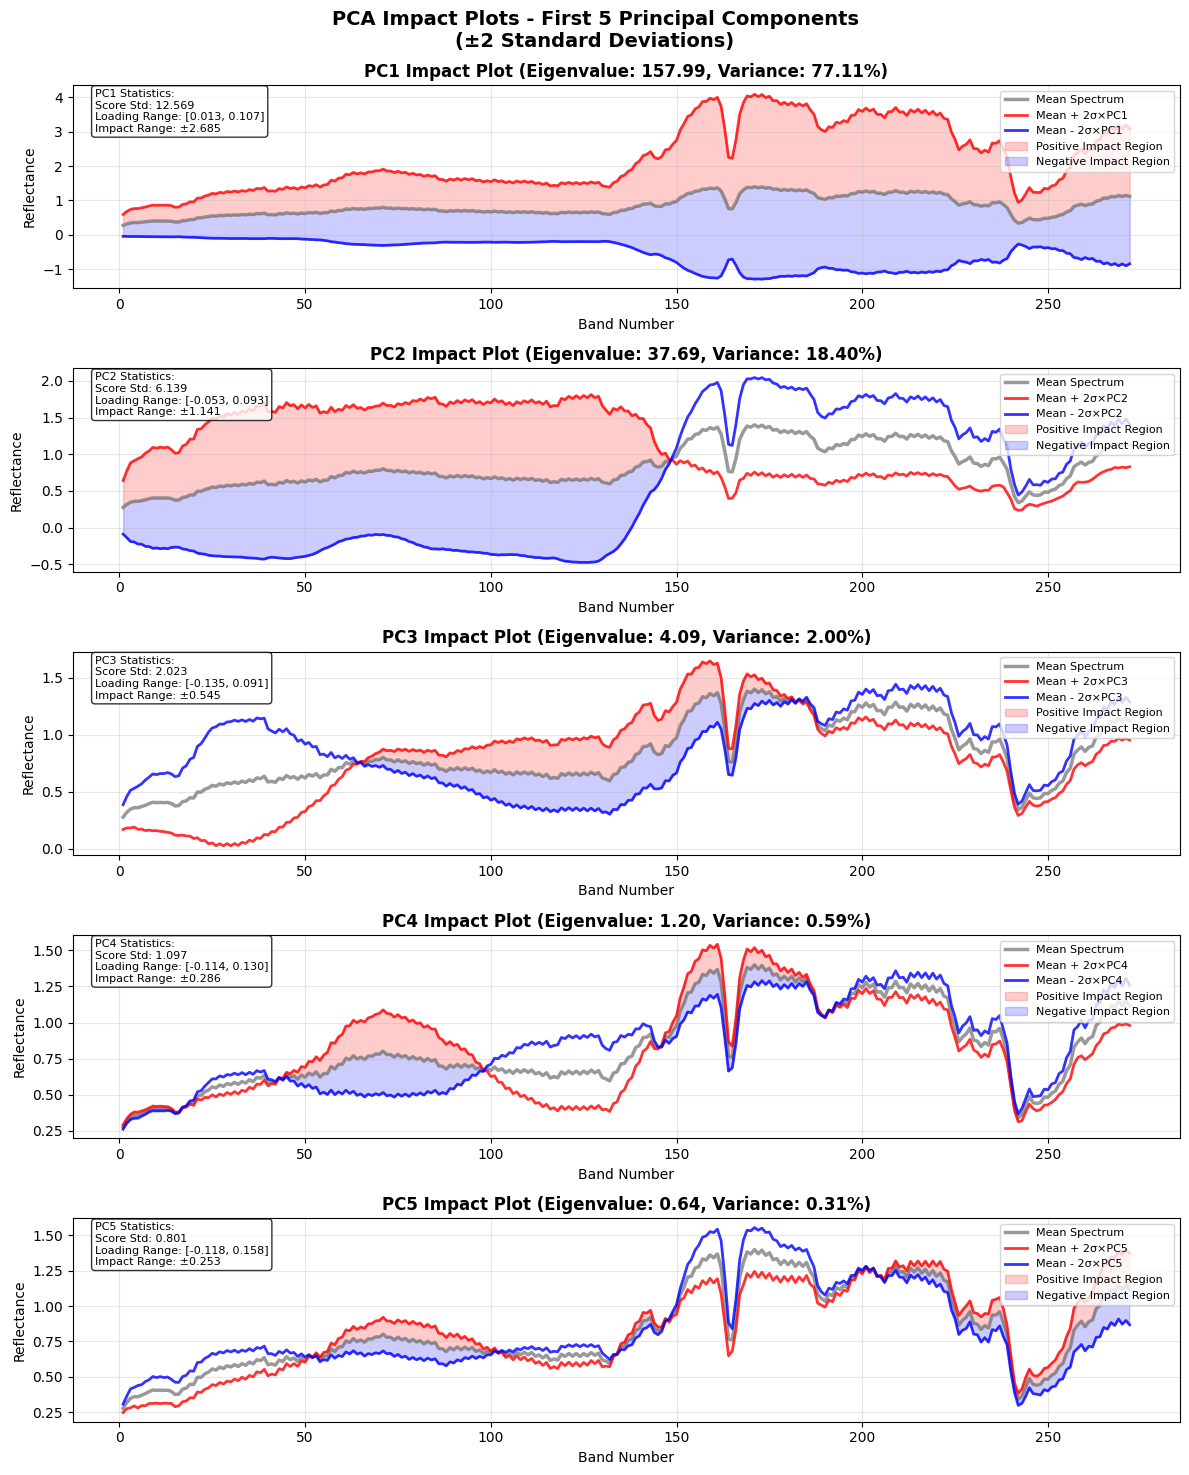


CREATING COMBINED IMPACT PLOT
✓ Saved: pca_combined_impact_plot.png


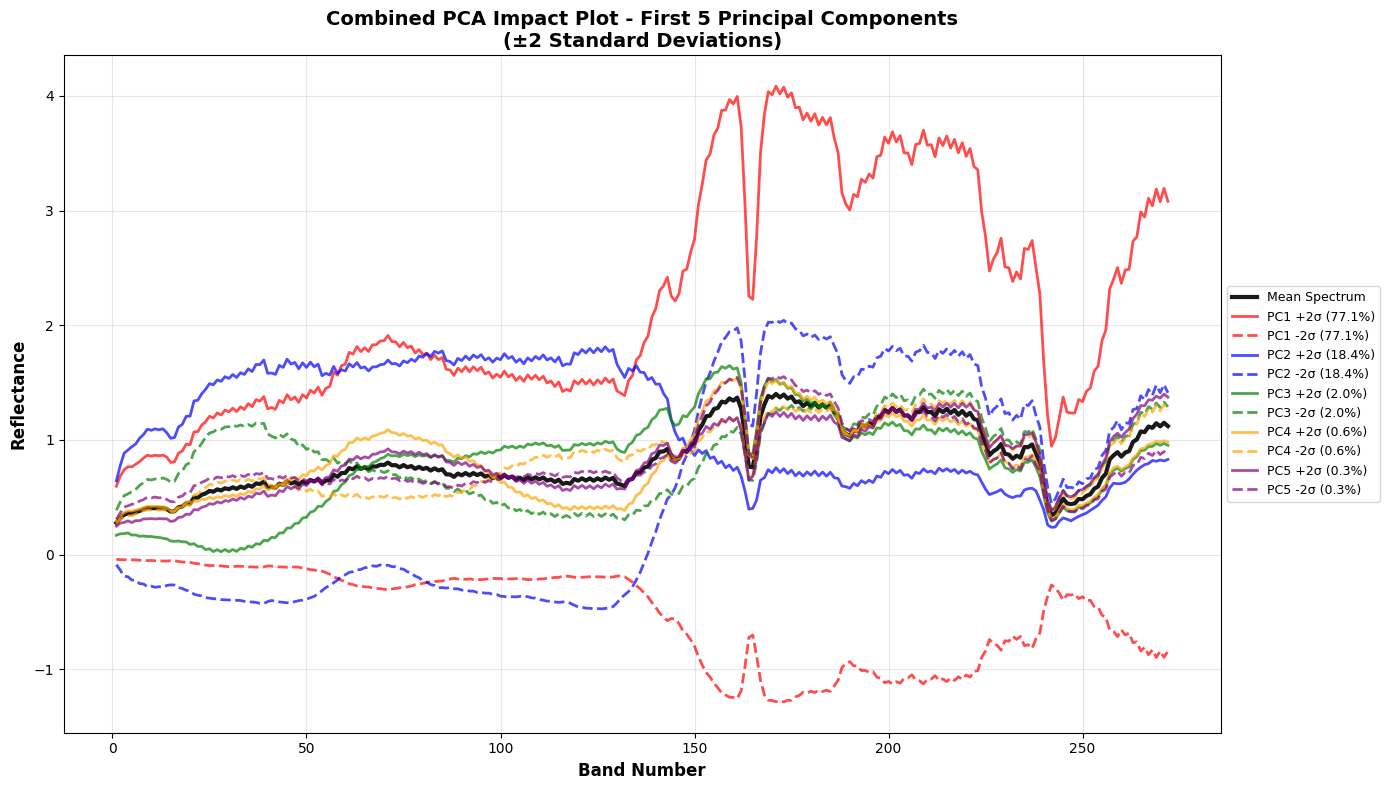


ANALYZING PC LOADINGS

PC1 Loading Analysis:
  Range: [0.0127, 0.1068]
  Max at band 171: 0.1068
  Min at band 1: 0.0127

PC2 Loading Analysis:
  Range: [-0.0535, 0.0929]
  Max at band 127: 0.0929
  Min at band 170: -0.0535

PC3 Loading Analysis:
  Range: [-0.1347, 0.0905]
  Max at band 142: 0.0905
  Min at band 30: -0.1347

PC4 Loading Analysis:
  Range: [-0.1137, 0.1304]
  Max at band 71: 0.1304
  Min at band 126: -0.1137

PC5 Loading Analysis:
  Range: [-0.1177, 0.1578]
  Max at band 272: 0.1578
  Min at band 162: -0.1177

✓ Saved: pc_loadings_analysis.png


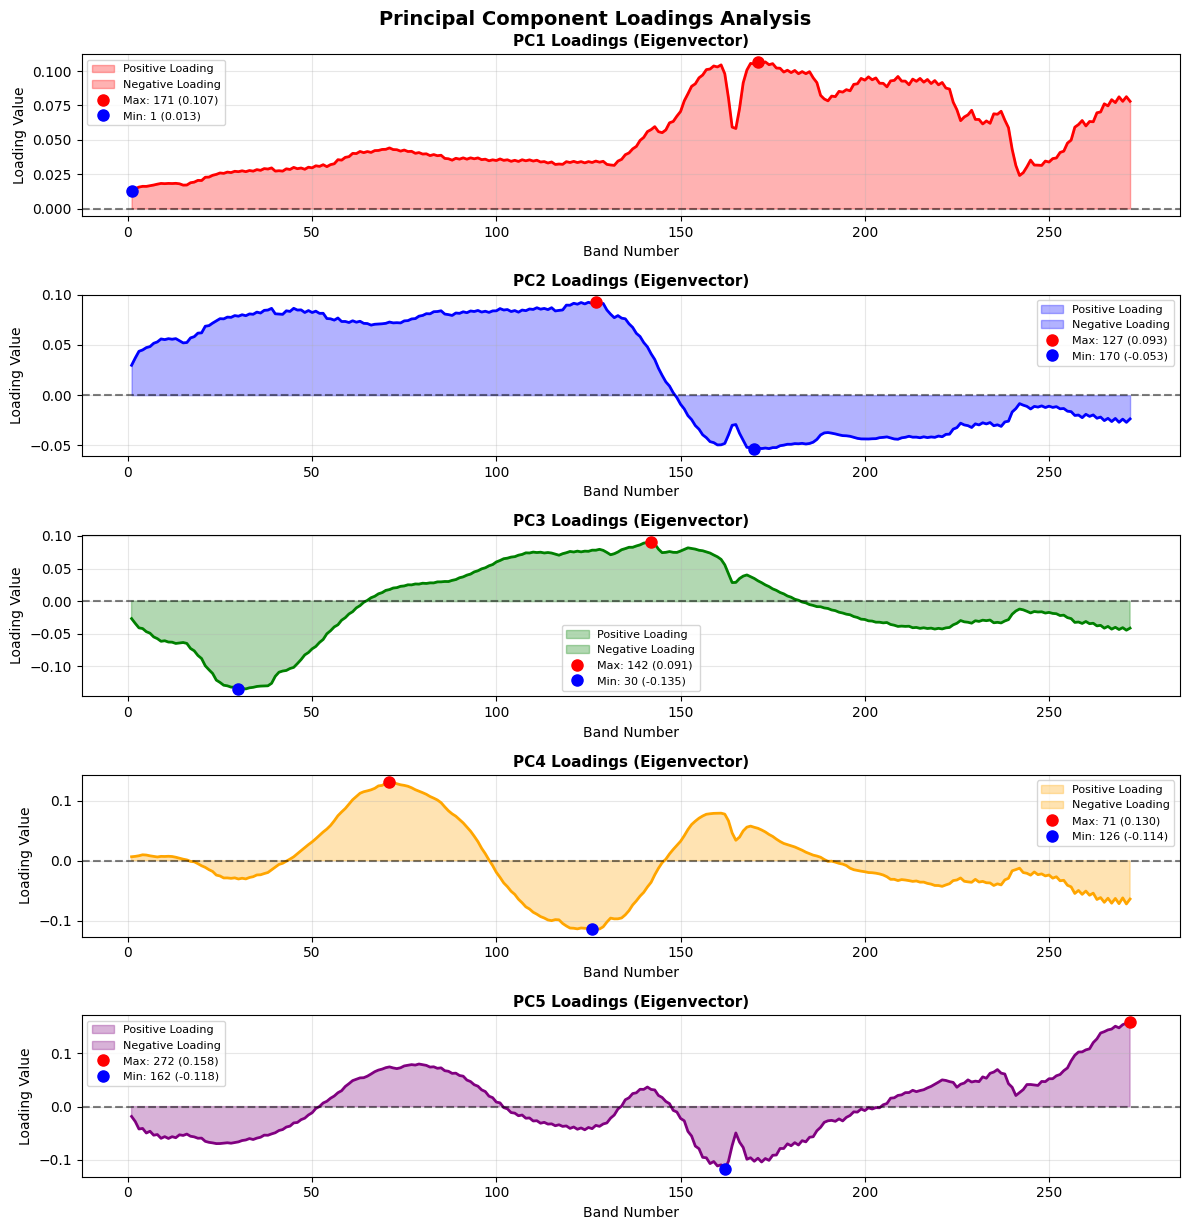


✓✓✓ IMPACT PLOT ANALYSIS COMPLETE!

Generated files:
  • pca_impact_plots_bajorski.png - Individual impact plots
  • pca_combined_impact_plot.png - Combined impact plot
  • pc_loadings_analysis.png - PC loadings analysis

Interpretation Guide:
  • Mean spectrum (gray/black): baseline/average spectral signature
  • Positive impact (red): how spectrum changes with +2σ of PC
  • Negative impact (blue): how spectrum changes with -2σ of PC
  • Filled regions: show the range of variability each PC contributes
  • PC loadings: show which spectral features each PC emphasizes



In [24]:


import numpy as np
import matplotlib.pyplot as plt
import spectral as spy
from scipy.linalg import svd

# ============================================================================
# CUSTOM PCA FUNCTION
# ============================================================================

def principal_component_analysis(data):
  
    print("Starting PCA analysis...")
    
    # Check the input data
    if data.ndim != 2:
        raise ValueError("Data must be 2D (samples × features)")
    
    m, d = data.shape
    print(f"Data shape: {data.shape} ({m} samples, {d} features)")
    
    # Step 1: Mean-center the data
    # This is important - PCA needs centered data
    feature_means = np.mean(data, axis=0)
    standardized_data = data - feature_means
    
    print(f"Mean-centered data. Range: [{standardized_data.min():.3f}, {standardized_data.max():.3f}]")
    
    # Step 2: Perform SVD
    # SVD gives us U, s (singular values), Vt
    U, s, Vt = svd(standardized_data, full_matrices=False)
    
    # Step 3: Convert singular values to eigenvalues
    # The eigenvalues are s^2 / (m-1)
    eigenvalues = (s ** 2) / (m - 1)
    eigenvalues = eigenvalues[:d]  # Make sure we have d eigenvalues
    
    # Step 4: Principal components are the columns of V (transpose of Vt)
    pcs = Vt.T
    
    # Let me check if eigenvalues are sorted (they should be)
    print(f"Eigenvalues sorted? {np.all(eigenvalues[:-1] >= eigenvalues[1:])}")
    print(f"First 5 eigenvalues: {eigenvalues[:5]}")
    
    return pcs, eigenvalues, standardized_data, feature_means


# ============================================================================
# LOAD DATA AND COMPUTE PCA
# ============================================================================

def load_and_compute_pca(hdr_file='tait_labsphere.hdr', n_components=5):

    print("=" * 70)
    print("LOADING DATA FOR IMPACT PLOT ANALYSIS")
    print("=" * 70)

    # Load data
    print(f"Reading hyperspectral data from: {hdr_file}")
    img = spy.open_image(hdr_file)
    
    print(f"\nImage info:")
    print(f"  Shape: {img.shape}")
    print(f"  Rows: {img.nrows}, Cols: {img.ncols}, Bands: {img.nbands}")
    
    # Load data into memory
    data = img.load()
    
    # Reshape from 3D (rows, cols, bands) to 2D (pixels, bands)
    rows, cols, bands = data.shape
    reshaped_data = data.reshape(rows * cols, bands)
    
    print(f"\nReshaped data: {reshaped_data.shape}")
    
    # Apply custom PCA
    print("\n" + "="*70)
    print("PERFORMING PCA USING CUSTOM FUNCTION")
    print("="*70)
    pcs, eigenvalues, centered_data, mean_spectrum = principal_component_analysis(reshaped_data)
    
    # Calculate explained variance ratio
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = eigenvalues / total_variance
    
    print(f"\nPCA Summary:")
    print(f"  Mean spectrum shape: {mean_spectrum.shape}")
    print(f"  PC matrix shape: {pcs.shape}")
    print(f"  Eigenvalues shape: {eigenvalues.shape}")
    print(f"  Total variance: {total_variance:.4f}")
    
    # Extract first n_components for analysis
    pc_loadings = pcs[:, :n_components]  # Shape: (bands, n_components)
    eigenvalues_subset = eigenvalues[:n_components]
    explained_var_ratio_subset = explained_variance_ratio[:n_components]
    
    print(f"\nExtracting first {n_components} components:")
    print(f"  PC loadings shape: {pc_loadings.shape}")
    print(f"  Total variance explained: {np.sum(explained_var_ratio_subset)*100:.2f}%")
    
    # Calculate PC scores by projecting centered data onto PCs
    # PC scores = centered_data @ pc_loadings
    pc_scores = centered_data @ pc_loadings  # Shape: (n_pixels, n_components)
    
    print(f"  PC scores shape: {pc_scores.shape}")

    return mean_spectrum, pc_loadings, pc_scores, eigenvalues_subset, explained_var_ratio_subset


# ============================================================================
# IMPACT PLOT IMPLEMENTATION
# ============================================================================

def create_impact_plots(mean_spectrum, pc_loadings, pc_scores, eigenvalues,
                       explained_variance_ratio, wavelengths=None, k_std=2):
  
    print("\n" + "=" * 70)
    print("CREATING IMPACT PLOTS (BAJORSKI'S METHOD)")
    print("=" * 70)

    bands, n_components = pc_loadings.shape

    
    if wavelengths is None:
        wavelengths = np.arange(1, bands + 1)
        x_label = 'Band Number'
    else:
        x_label = 'Wavelength (nm)'

    print(f"\nCreating impact plots for {n_components} principal components")
    print(f"Using k = {k_std} standard deviations for impact calculation")

    # Create subplots
    fig, axes = plt.subplots(n_components, 1, figsize=(12, 3*n_components))
    if n_components == 1:
        axes = [axes]

    # Colors for the plots
    color_mean = 'gray'
    color_positive = 'red'
    color_negative = 'blue'

    for i in range(n_components):
        ax = axes[i]

        # Get PC loading for this component
        pc_loading = pc_loadings[:, i]  # Shape: (bands,)

        # Calculate standard deviation of PC scores
        pc_scores_std = np.std(pc_scores[:, i])

        # Calculate impact spectra
        # Positive impact: mean + k*std*PC_loading
        positive_impact = mean_spectrum + k_std * pc_scores_std * pc_loading

        # Negative impact: mean - k*std*PC_loading
        negative_impact = mean_spectrum - k_std * pc_scores_std * pc_loading

        # Plot the three spectra
        ax.plot(wavelengths, mean_spectrum, color=color_mean, linewidth=2.5,
               label='Mean Spectrum', alpha=0.8)
        ax.plot(wavelengths, positive_impact, color=color_positive, linewidth=2,
               label=f'Mean + {k_std}σ×PC{i+1}', alpha=0.8)
        ax.plot(wavelengths, negative_impact, color=color_negative, linewidth=2,
               label=f'Mean - {k_std}σ×PC{i+1}', alpha=0.8)

        # Fill between to show impact regions
        ax.fill_between(wavelengths, mean_spectrum, positive_impact,
                       where=(positive_impact >= mean_spectrum),
                       color=color_positive, alpha=0.2, interpolate=True,
                       label='Positive Impact Region')
        ax.fill_between(wavelengths, mean_spectrum, negative_impact,
                       where=(negative_impact <= mean_spectrum),
                       color=color_negative, alpha=0.2, interpolate=True,
                       label='Negative Impact Region')

        # Formatting
        variance_pct = explained_variance_ratio[i] * 100
        ax.set_title(f'PC{i+1} Impact Plot (Eigenvalue: {eigenvalues[i]:.2f}, '
                    f'Variance: {variance_pct:.2f}%)',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Reflectance', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)

        # Add statistics text box
        stats_text = (f'PC{i+1} Statistics:\n'
                     f'Score Std: {pc_scores_std:.3f}\n'
                     f'Loading Range: [{np.min(pc_loading):.3f}, {np.max(pc_loading):.3f}]\n'
                     f'Impact Range: ±{k_std*pc_scores_std*np.max(np.abs(pc_loading)):.3f}')

        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               fontsize=8, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Print analysis
        print(f"\nPC{i+1} Analysis:")
        print(f"  Eigenvalue: {eigenvalues[i]:.4f}")
        print(f"  Variance explained: {variance_pct:.2f}%")
        print(f"  PC scores std: {pc_scores_std:.4f}")
        print(f"  PC loading range: [{np.min(pc_loading):.4f}, {np.max(pc_loading):.4f}]")
        print(f"  Maximum impact magnitude: ±{k_std*pc_scores_std*np.max(np.abs(pc_loading)):.4f}")

    plt.suptitle(f'PCA Impact Plots - First {n_components} Principal Components\n'
                f'(±{k_std} Standard Deviations)',
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig('pca_impact_plots_bajorski.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: pca_impact_plots_bajorski.png")
    plt.show()

    return fig


def create_combined_impact_plot(mean_spectrum, pc_loadings, pc_scores,
                               eigenvalues, explained_variance_ratio,
                               wavelengths=None, k_std=2):
   

    print("\n" + "=" * 70)
    print("CREATING COMBINED IMPACT PLOT")
    print("=" * 70)

    bands, n_components = pc_loadings.shape

    if wavelengths is None:
        wavelengths = np.arange(1, bands + 1)
        x_label = 'Band Number'
    else:
        x_label = 'Wavelength (nm)'

    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot mean spectrum
    ax.plot(wavelengths, mean_spectrum, color='black', linewidth=3,
           label='Mean Spectrum', alpha=0.9)

    # Colors for different PCs
    colors = ['red', 'blue', 'green', 'orange', 'purple']

    for i in range(n_components):
        pc_loading = pc_loadings[:, i]
        pc_scores_std = np.std(pc_scores[:, i])

        # Calculate impact spectra
        positive_impact = mean_spectrum + k_std * pc_scores_std * pc_loading
        negative_impact = mean_spectrum - k_std * pc_scores_std * pc_loading

        color = colors[i % len(colors)]
        variance_pct = explained_variance_ratio[i] * 100

        # Plot impacts
        ax.plot(wavelengths, positive_impact, color=color, linewidth=2,
               linestyle='-', alpha=0.7,
               label=f'PC{i+1} +{k_std}σ ({variance_pct:.1f}%)')
        ax.plot(wavelengths, negative_impact, color=color, linewidth=2,
               linestyle='--', alpha=0.7,
               label=f'PC{i+1} -{k_std}σ ({variance_pct:.1f}%)')

    ax.set_title(f'Combined PCA Impact Plot - First {n_components} Principal Components\n'
                f'(±{k_std} Standard Deviations)',
                fontsize=14, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Reflectance', fontsize=12, fontweight='bold')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('pca_combined_impact_plot.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved: pca_combined_impact_plot.png")
    plt.show()

    return fig


def analyze_pc_loadings(pc_loadings, wavelengths=None):
   

    print("\n" + "=" * 70)
    print("ANALYZING PC LOADINGS")
    print("=" * 70)

    bands, n_components = pc_loadings.shape

    if wavelengths is None:
        wavelengths = np.arange(1, bands + 1)
        x_label = 'Band Number'
    else:
        x_label = 'Wavelength (nm)'

    fig, axes = plt.subplots(n_components, 1, figsize=(12, 2.5*n_components))
    if n_components == 1:
        axes = [axes]

    colors = ['red', 'blue', 'green', 'orange', 'purple']

    for i in range(n_components):
        ax = axes[i]
        pc_loading = pc_loadings[:, i]
        color = colors[i % len(colors)]

        # Plot PC loading
        ax.plot(wavelengths, pc_loading, color=color, linewidth=2)
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

        # Highlight positive and negative regions
        ax.fill_between(wavelengths, 0, pc_loading, where=(pc_loading > 0),
                       color=color, alpha=0.3, label='Positive Loading')
        ax.fill_between(wavelengths, 0, pc_loading, where=(pc_loading < 0),
                       color=color, alpha=0.3, label='Negative Loading')

        ax.set_title(f'PC{i+1} Loadings (Eigenvector)', fontsize=11, fontweight='bold')
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Loading Value', fontsize=10)
        ax.grid(True, alpha=0.3)

        # Find peaks and valleys
        max_idx = np.argmax(pc_loading)
        min_idx = np.argmin(pc_loading)

        ax.plot(wavelengths[max_idx], pc_loading[max_idx], 'ro', markersize=8,
               label=f'Max: {wavelengths[max_idx]:.0f} ({pc_loading[max_idx]:.3f})')
        ax.plot(wavelengths[min_idx], pc_loading[min_idx], 'bo', markersize=8,
               label=f'Min: {wavelengths[min_idx]:.0f} ({pc_loading[min_idx]:.3f})')

        ax.legend(fontsize=8)

        print(f"\nPC{i+1} Loading Analysis:")
        print(f"  Range: [{np.min(pc_loading):.4f}, {np.max(pc_loading):.4f}]")
        print(f"  Max at band {wavelengths[max_idx]:.0f}: {pc_loading[max_idx]:.4f}")
        print(f"  Min at band {wavelengths[min_idx]:.0f}: {pc_loading[min_idx]:.4f}")

    plt.suptitle(f'Principal Component Loadings Analysis',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('pc_loadings_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: pc_loadings_analysis.png")
    plt.show()

    return fig


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Complete impact plot analysis workflow using custom PCA function.
    """

    print("\n" + "=" * 70)
    print("IMPACT PLOT ANALYSIS - BAJORSKI'S METHOD")
    print("Using Custom PCA Function")
    print("=" * 70)

    # Step 1: Load data and compute PCA using custom function
    mean_spectrum, pc_loadings, pc_scores, eigenvalues, explained_var_ratio = \
        load_and_compute_pca(
            hdr_file='tait_labsphere.hdr',
            n_components=5
        )

    # Step 2: Create individual impact plots
    fig1 = create_impact_plots(
        mean_spectrum, pc_loadings, pc_scores, eigenvalues, explained_var_ratio,
        wavelengths=None,  # Use band numbers; set to actual wavelengths if available
        k_std=2  # ±2 standard deviations
    )

    # Step 3: Create combined impact plot
    fig2 = create_combined_impact_plot(
        mean_spectrum, pc_loadings, pc_scores, eigenvalues, explained_var_ratio,
        wavelengths=None,
        k_std=2
    )

    # Step 4: Analyze PC loadings
    fig3 = analyze_pc_loadings(pc_loadings, wavelengths=None)

    print("\n" + "=" * 70)
    print("✓✓✓ IMPACT PLOT ANALYSIS COMPLETE!")
    print("=" * 70)

    print("\nGenerated files:")
    print("  • pca_impact_plots_bajorski.png - Individual impact plots")
    print("  • pca_combined_impact_plot.png - Combined impact plot")
    print("  • pc_loadings_analysis.png - PC loadings analysis")

    print("\nInterpretation Guide:")
    print("  • Mean spectrum (gray/black): baseline/average spectral signature")
    print("  • Positive impact (red): how spectrum changes with +2σ of PC")
    print("  • Negative impact (blue): how spectrum changes with -2σ of PC")
    print("  • Filled regions: show the range of variability each PC contributes")
    print("  • PC loadings: show which spectral features each PC emphasizes")

    print("\n" + "=" * 70)

    return mean_spectrum, pc_loadings, pc_scores, eigenvalues, explained_var_ratio


# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    mean_spectrum, pc_loadings, pc_scores, eigenvalues, explained_var_ratio = main()